In [1]:
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from scipy import *

### Operator Initialization

In [2]:
#pauli operators
s_x = np.array([[0,1],[1,0]], dtype=complex)
s_y = np.array([[0,-1j],[1j,0]], dtype=complex)
s_z = np.array([[1,0],[0,-1]], dtype=complex)
id = np.array([[1,0],[0,1]], dtype=complex)
#projection operators
proj_0 = np.array([[1,0],[0,0]], dtype=complex)
proj_1 = np.array([[0,0],[0,1]], dtype=complex)

### Parameters (gammas, omega, delta, time_range, Hamiltonian)

In [3]:
omega = 2*np.pi
delta = 1
gamma_phase = .4 #phase damping rate
gamma_amp = .4 #amplitude damping rate
gamma_flip = .3 #bit flip rate
gamma_id = .3 #identity "damping" rate
times = np.linspace(0,10,5000) #time span to integrate over

#Hamiltonian def for 1 qubit - is this correct? 
#H_1qubit = -.5*delta*s_z + .5*omega*s_x 
#H = np.kron(id, np.kron(id, id)) # placeholder Hamiltonian is 3 qubit identity
H_sing = -.5*delta*s_z + .5*omega*s_x
H  = np.kron(H_sing, np.kron(id, id)) + np.kron(id, np.kron(H_sing, id)) + np.kron(id, np.kron(id, H_sing))


channel_strings = ['bit_flip', 'amp_damp', 'phase_damp', 'id'] #feed our simulate method an array of strings to represent the channels we apply to each qubit

### Kraus Operators

In [4]:
#bit flip (K0 = sqrt(1-p)*I; K1 = sqrt(p)*X)
def bit_flip(p):
    K0 = np.sqrt(1-p)*id
    K1 = np.sqrt(p)*s_x
    return [K0,K1]
#amplitude damping channel (defined by matrices its easier that way)
def amp_damp(p):
    K0 = np.array([[1,0], [0, np.sqrt(1-p)]], dtype = complex)
    K1 = np.array([[0,np.sqrt(p)], [0, 0]], dtype = complex)
    return [K0,K1]
#phase damping (K0 = sqrt(1-p)*I; K1 = sqrt(p)*Z)
def phase_damp(p):
    K0 = np.sqrt(1-p)*id
    K1 = np.sqrt(p)*s_z
    return [K0,K1]
def id_channel(p): #just apply identity to some bits, we'd still expect to see some level of damping nosie though
    K0 = id*np.sqrt(1-p)
    return [K0]

In [5]:
# Calculate the effect of the Kraus operators on density matrix rho
def kraus_compute(rho, op_arr):
    rho_f = np.zeros_like(rho, dtype=complex)
    for K in op_arr:
        rho_f += K @ rho @ K.conjugate().T #compute K*rho*Kdag for each operator in a channel
    return rho_f


### Master Equation Helper

In [6]:
def master_helper(rho, H, times, op):
    H = Qobj(H, dims=[[2,2,2],[2,2,2]]) #cast Hamiltonian to qutip object
    rho = Qobj(rho, dims=[[2,2,2],[2,2,2]]) #cast density matrix to qutip object
    op = Qobj(op, dims=[[2,2,2],[2,2,2]])
    #print(op)
    op_x0 = tensor(gamma_flip*sigmax(), gamma_id*qeye(2), gamma_id*qeye(2))
    op_x1 = tensor(gamma_id*qeye(2), gamma_flip*sigmax(), gamma_id*qeye(2))
    op_x2 = tensor(gamma_id*qeye(2), gamma_id*qeye(2), gamma_flip*sigmax())
    result = mesolve(H, rho, times, [op], [op_x0, op_x1, op_x2])
    return result 

### Simulation

In [7]:
#cast to Qobj to turn into qutip object, pass through qutip mesolve
def simulate(channels, rho0): #sim method takes a string representing the channel, a float representing the value of gamma/prob for a channel, and the system's initial hamiltonian
    collapse_list = []
    rhos = []
    for channel in channels: #work out operators/how evolution works. Figure out what to feed master_helper
        if channel == channel_strings[0]:
            operators = bit_flip(gamma_flip)
            rho_f = kraus_compute(rho0, operators)
            collapse_list.append(np.sqrt(gamma_flip)*s_x)
            rhos.append(rho_f)
            #return master_helper(rho_f, H, times, [np.sqrt(gamma)*sigmax()]) 
        elif channel == channel_strings[1]:
            operators = amp_damp(gamma_amp)
            rho_f = kraus_compute(rho0, operators)
            collapse_list.append(np.sqrt(gamma_amp)*s_p)
            rhos.append(rho_f)
            #return master_helper(rho_f, H, times, [np.sqrt(gamma)*sigmap()]) 
        elif channel == channel_strings[2]:
            operators = phase_damp(gamma_phase)
            rho_f = kraus_compute(rho0, operators)
            collapse_list.append(np.sqrt(gamma_phase)*s_z)
            rhos.append(rho_f)
            #return master_helper(rho_f, H, times, [np.sqrt(gamma)*sigmaz()])
        else:
            opreators = id_channel(gamma_id)
            rho_f = kraus_compute(rho0, operators)
            collapse_list.append(np.sqrt(gamma_id)*id)
            rhos.append(rho_f)
            #return master_helper(rho_f, H, times, [np.sqrt(gamma)*qeye(1)])
    rho_f_tens = np.kron(rhos[0], np.kron(rhos[1],rhos[2]))
    collapse_op_tens = np.kron(collapse_list[0], np.kron(collapse_list[1],collapse_list[2]))
    return master_helper(rho_f_tens, H, times, collapse_op_tens)

Text(0.5, 1.0, 'Evolution of Channel')

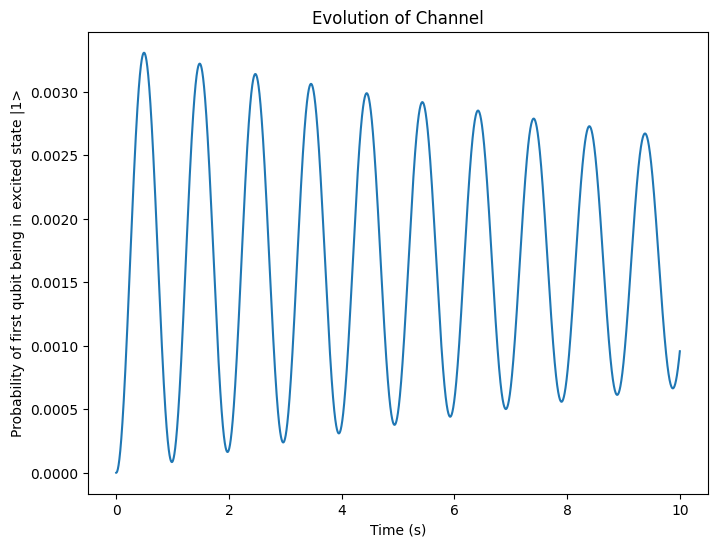

In [8]:
ch = ['bit_flip', 'id', 'id']
result = simulate(ch,proj_1)
plt.figure(figsize=(8,6))
plt.plot(result.times, result.expect[0])
plt.xlabel("Time (s)")
plt.ylabel("Probability of first qubit being in excited state |1>")
plt.title("Evolution of Channel")

### CZ and iSWAP gate defs

In [9]:
def custom_gate_expand_2toN(twoq_gate, target_list):
    N=3
    # Ensure targets are in ascending order.
    targets = sorted(target_list)
    total_dim = 2**N
    full_mat = np.zeros((total_dim, total_dim), dtype=complex)

    # Loop over all basis elements.
    for i in range(total_dim):
        # Represent i in N bits.
        bits_i = [(i >> (N - 1 - k)) & 1 for k in range(N)]
        for j in range(total_dim):
            bits_j = [(j >> (N - 1 - k)) & 1 for k in range(N)]
            # For qubits that are not in targets, 
            # the bits must be the same in i and j for a nonzero matrix element.
            valid = True
            for k in range(N):
                if k not in targets and bits_i[k] != bits_j[k]:
                    valid = False
                    break
            if not valid:
                continue
            # For the target qubits, obtain 2-bit indices.
            idx_i = bits_i[targets[0]] * 2 + bits_i[targets[1]]
            idx_j = bits_j[targets[0]] * 2 + bits_j[targets[1]]
            full_mat[i, j] = twoq_gate[idx_i, idx_j]

    # Set the dimensions for an N-qubit operator.
    dims = [[2 for _ in range(N)], [2 for _ in range(N)]]
    return Qobj(full_mat, dims=dims)

In [10]:
def cz(control, target): #janky for if you want to cz upward
    p0 = basis(2, 0) * basis(2, 0).dag()
    p1 = basis(2, 1) * basis(2, 1).dag()
    cz_2 = tensor(qeye(2), qeye(2)) - 2*tensor(p1, p1)
    cz_2 = cz_2.full()
    return custom_gate_expand_2toN(cz_2, [control, target])
cz(0,0)

Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]

In [11]:
def iSWAP(control, target):
    iswap_2 = np.array([[1,0,0,0],
                        [0,0,1j,0],
                        [0,1j,0,0],
                        [0,0,0,1]], dtype=complex)
    return custom_gate_expand_2toN(iswap_2, [control, target])
iSWAP(0,1)

Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]